In [1]:
!pip install pyqpanda3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.7/31.7 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.7/531.7 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.3 MB/s eta 0:00:00


# **Common Quantum Logic Gates in Matrix**

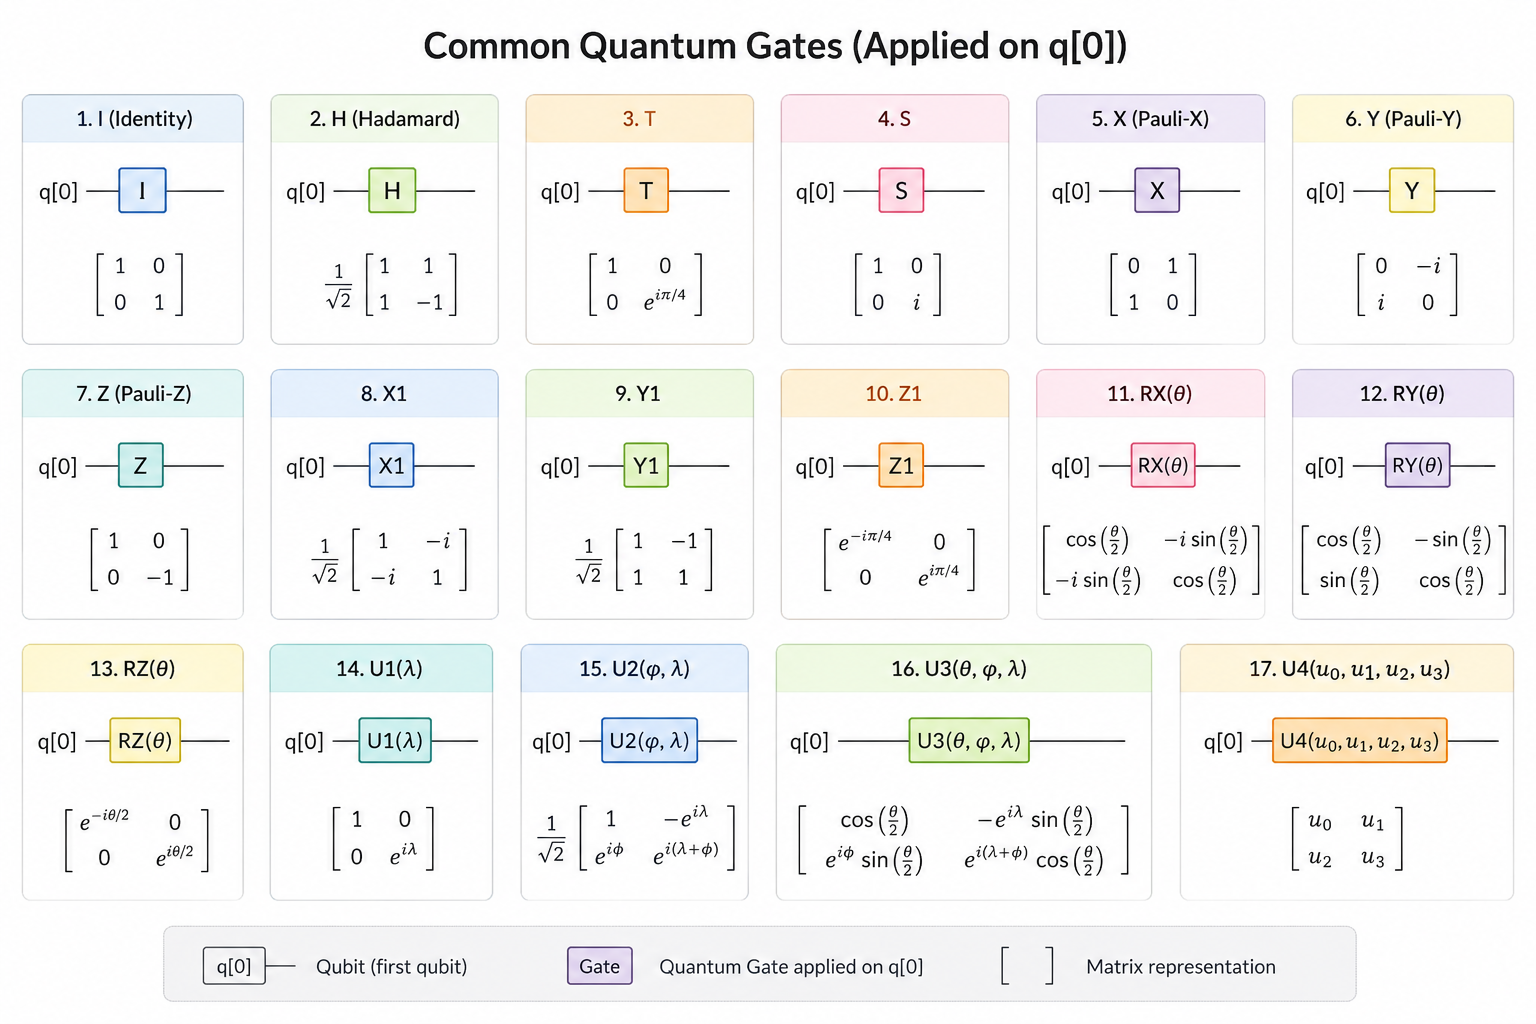



| **Gate** | **Name** | **Matrix** |
|---|---|---|
| I | `I` | $$\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$ |
| H | `Hadamard` | $$\begin{bmatrix} \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} \end{bmatrix}$$ |
| T | `T` | $$\begin{bmatrix} 1 & 0 \\ 0 & \exp\left(\frac{i\pi}{4}\right) \end{bmatrix}$$ |
| S | `S` | $$\begin{bmatrix} 1 & 0 \\ 0 & i \end{bmatrix}$$ |
| X | `Pauli-X` | $$\begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}$$ |
| Y | `Pauli-Y` | $$\begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix}$$ |
| Z | `Pauli-Z` | $$\begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}$$ |
| X1 | `X1` | $$\begin{bmatrix} \frac{1}{\sqrt{2}} & -\frac{i}{\sqrt{2}} \\ -\frac{i}{\sqrt{2}} & \frac{1}{\sqrt{2}} \end{bmatrix}$$ |
| Y1 | `Y1` | $$\begin{bmatrix} \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \end{bmatrix}$$ |
| Z1 | `Z1` | $$\begin{bmatrix} \exp\left(-\frac{i\pi}{4}\right) & 0 \\ 0 & \exp\left(\frac{i\pi}{4}\right) \end{bmatrix}$$ |
| RX | `RX` | $$\begin{bmatrix} \cos\left(\frac{\theta}{2}\right) & -i\sin\left(\frac{\theta}{2}\right) \\ -i\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right) \end{bmatrix}$$ |
| RY | `RY` | $$\begin{bmatrix} \cos\left(\frac{\theta}{2}\right) & -\sin\left(\frac{\theta}{2}\right) \\ \sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right) \end{bmatrix}$$ |
| RZ | `RZ` | $$\begin{bmatrix} \exp\left(-\frac{i\theta}{2}\right) & 0 \\ 0 & \exp\left(\frac{i\theta}{2}\right) \end{bmatrix}$$ |
| U1 | `U1` | $$\begin{bmatrix} 1 & 0 \\ 0 & \exp(i\theta) \end{bmatrix}$$ |
| U2 | `U2` | $$\begin{bmatrix} \frac{1}{\sqrt{2}} & -\frac{\exp(i\lambda)}{\sqrt{2}} \\ \frac{\exp(i\phi)}{\sqrt{2}} & \frac{\exp(i\lambda+i\phi)}{\sqrt{2}} \end{bmatrix}$$ |
| U3 | `U3` | $$\begin{bmatrix} \cos\left(\frac{\theta}{2}\right) & -\exp(i\lambda)\sin\left(\frac{\theta}{2}\right) \\ \exp(i\phi)\sin\left(\frac{\theta}{2}\right) & \exp(i\lambda+i\phi)\cos\left(\frac{\theta}{2}\right) \end{bmatrix}$$ |
| U4 | `U4` | $$\begin{bmatrix} u_0 & u_1 \\ u_2 & u_3 \end{bmatrix}$$ |

In [2]:
from pyqpanda3.core import *

theta = 3.141592653589793 / 2

prog = QProg()

prog << I(0)
prog << H(0)
prog << T(0)
prog << S(0)
prog << X(0)
prog << Y(0)
prog << Z(0)
prog << X1(0)
prog << Y1(0)
prog << Z1(0)
prog << RX(0, theta)
prog << RY(0, theta)
prog << RZ(0, theta)
prog << U1(0, theta)
prog << U2(0, 0.0, 0.0)
prog << U3(0, theta, 0.0, 0.0)
prog << U4(0, 0.0, 0.0, 0.0, 0.0)

qvm = CPUQVM()
qvm.run(prog, 1)

print(qvm.result().get_state_vector())

[(-0.7071067811865478+1.1102230246251565e-16j), (-0.5000000000000002-0.5j)]


In [5]:
from pyqpanda3.core import *

# Create a quantum program with 3 qubits
prog = QProg(3)

q = prog.qubits()

# q0: Apply single-qubit gates
prog << H(q[0])
prog << I(q[0])
prog << T(q[0])
prog << S(q[0])
prog << X(q[0])
prog << Y(q[0])
prog << Z(q[0])
prog << X1(q[0])
prog << Y1(q[0])
prog << Z1(q[0])

# Rotation gates
theta = 3.141592653589793 / 2

prog << RX(q[0], theta)
prog << RY(q[0], theta)
prog << RZ(q[0], theta)

# U gates
prog << U1(q[0], theta)
prog << U2(q[0], 0.0, 0.0)
prog << U3(q[0], theta, 0.0, 0.0)

# Two-qubit gates
prog << CNOT(q[0], q[1])
prog << CNOT(q[1], q[2])



┌─┐ ┌─┐ ┌─┐ ┌─┐ ┌─┐ ┌─┐ ┌─┐ ┌──┐ ┌──┐ ┌──┐ ┌──┐ ┌──┐ ┌──┐ ┌──┐ ┌──┐ ┌──┐               
q_0:  |0>─┤H├ ┤I├ ┤T├ ┤S├ ┤X├ ┤Y├ ┤Z├ ┤X1├ ┤Y1├ ┤Z1├ ┤RX├ ┤RY├ ┤RZ├ ┤U1├ ┤U2├ ┤U3├ ───*── ────── 
          └─┘ └─┘ └─┘ └─┘ └─┘ └─┘ └─┘ └──┘ └──┘ └──┘ └──┘ └──┘ └──┘ └──┘ └──┘ └──┘ ┌──┴─┐        
q_1:  |0>──── ─── ─── ─── ─── ─── ─── ──── ──── ──── ──── ──── ──── ──── ──── ──── ┤CNOT├ ───*── 
                                                                                   └────┘ ┌──┴─┐ 
q_2:  |0>──── ─── ─── ─── ─── ─── ─── ──── ──── ──── ──── ──── ──── ──── ──── ──── ────── ┤CNOT├ 
                                                                                          └────┘ 
 c :   / ═══════════════════════════════════════════════════════════════════════════════════════

# **Multi-qubit Quantum Gates**



| **Gate** | **Name** | **Matrix** |
|---|---|---|
| CNOT | `CNOT` | $$\begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{bmatrix}$$ |
| MS | `MS` | $$\begin{bmatrix} \frac{1}{\sqrt{2}} & 0 & 0 & -\frac{i}{\sqrt{2}} \\ 0 & \frac{1}{\sqrt{2}} & -\frac{i}{\sqrt{2}} & 0 \\ 0 & -\frac{i}{\sqrt{2}} & \frac{1}{\sqrt{2}} & 0 \\ -\frac{i}{\sqrt{2}} & 0 & 0 & \frac{1}{\sqrt{2}} \end{bmatrix}$$ |
| CR | `CR` | $$\begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & \exp(i\theta) \end{bmatrix}$$ |
| iSWAP | `iSWAP` | $$\begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & \cos(\theta) & i\sin(\theta) & 0 \\ 0 & i\sin(\theta) & \cos(\theta) & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$ |
| SWAP | `SWAP` | $$\begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$ |
| CZ | `CZ` | $$\begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & -1 \end{bmatrix}$$ |
| CU | `CU` | $$\begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & u_0 & u_1 \\ 0 & 0 & u_2 & u_3 \end{bmatrix}$$ |
| RXX | `RXX` | $$\begin{bmatrix} \cos\left(\frac{\theta}{2}\right) & 0 & 0 & -i\sin\left(\frac{\theta}{2}\right) \\ 0 & \cos\left(\frac{\theta}{2}\right) & -i\sin\left(\frac{\theta}{2}\right) & 0 \\ 0 & -i\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right) & 0 \\ -i\sin\left(\frac{\theta}{2}\right) & 0 & 0 & \cos\left(\frac{\theta}{2}\right) \end{bmatrix}$$ |
| RYY | `RYY` | $$\begin{bmatrix} \cos\left(\frac{\theta}{2}\right) & 0 & 0 & i\sin\left(\frac{\theta}{2}\right) \\ 0 & \cos\left(\frac{\theta}{2}\right) & -i\sin\left(\frac{\theta}{2}\right) & 0 \\ 0 & -i\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right) & 0 \\ i\sin\left(\frac{\theta}{2}\right) & 0 & 0 & \cos\left(\frac{\theta}{2}\right) \end{bmatrix}$$ |
| RZZ | `RZZ` | $$\begin{bmatrix} \exp\left(-\frac{i\theta}{2}\right) & 0 & 0 & 0 \\ 0 & \exp\left(\frac{i\theta}{2}\right) & 0 & 0 \\ 0 & 0 & \exp\left(\frac{i\theta}{2}\right) & 0 \\ 0 & 0 & 0 & \exp\left(-\frac{i\theta}{2}\right) \end{bmatrix}$$ |
| RZX | `RZX` | $$\begin{bmatrix} \cos\left(\frac{\theta}{2}\right) & 0 & -i\sin\left(\frac{\theta}{2}\right) & 0 \\ 0 & \cos\left(\frac{\theta}{2}\right) & 0 & i\sin\left(\frac{\theta}{2}\right) \\ -i\sin\left(\frac{\theta}{2}\right) & 0 & \cos\left(\frac{\theta}{2}\right) & 0 \\ 0 & i\sin\left(\frac{\theta}{2}\right) & 0 & \cos\left(\frac{\theta}{2}\right) \end{bmatrix}$$ |
| Toffoli | `Toffoli` | $$\begin{bmatrix} 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\ 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \end{bmatrix}$$ |

In [10]:
from pyqpanda3.core import *
import numpy as np


# Create quantum 3 qubits
prog = QProg(3)

# Get qubits
q = prog.qubits()

# Angle
theta = np.pi / 2


prog << CNOT(q[0], q[1])


prog << MS(q[0], q[1])


prog << CR(q[0], q[1], theta)


#prog << iSWAP(q[0], q[1], theta)

prog << SWAP(q[0], q[1])

prog << CZ(q[0], q[1])

# CU(control, target, alpha, beta, gamma, delta)
prog << CU(q[0],q[1],np.pi,np.pi / 2,np.pi / 3,np.pi / 4)

prog << RXX(q[0], q[1], theta)

prog << RYY(q[0], q[1], theta)

prog << RZZ(q[0], q[1], theta)

prog << RZX(q[0], q[1], theta)


# q[0] = Control 1
# q[1] = Control 2
# q[2] = Target
#prog << Toffoli(q[0], q[1], q[2])

print(prog)


                 ┌──────┐                                                                              ┌───────────────────┐ >
q_0:  |0>────*── ┤0     ├ ────────*─────── X ──*─ ──────────────────────────*───────────────────────── ┤0                  ├ >
          ┌──┴─┐ │  MS  │ ┌───────┴──────┐ │ ┌─┴┐ ┌─────────────────────────┴────────────────────────┐ │  RXX(1.57079633)  │ >
q_1:  |0>─┤CNOT├ ┤1     ├ ┤CP(1.57079633)├ X ┤CZ├ ┤CU(3.14159265, 1.57079633, 1.04719755, 0.78539816)├ ┤1                  ├ >
          └────┘ └──────┘ └──────────────┘   └──┘ └──────────────────────────────────────────────────┘ └───────────────────┘ >
q_2:  |0>─────── ──────── ──────────────── ─ ──── ──────────────────────────────────────────────────── ───────────────────── >
                                                                                                                             >
 c :   / ═════════════════════════════════════════════════════════════════════════════════════════════════════